In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils

In [2]:
distances = torch.tensor(
    [[1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
     [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
     [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], 
     [15.5], [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], 
     [20.0]], 
    dtype=torch.float32)
times = torch.tensor(
    [[6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], 
     [37.15], [42.35], [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], 
     [69.45], [71.57], [72.8], [73.88], [76.34], [76.38], [78.34], [80.07], 
     [81.86], [84.45], [83.98], [86.55], [88.33], [86.83], [89.24], [88.11], 
     [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]], 
    dtype=torch.float32)

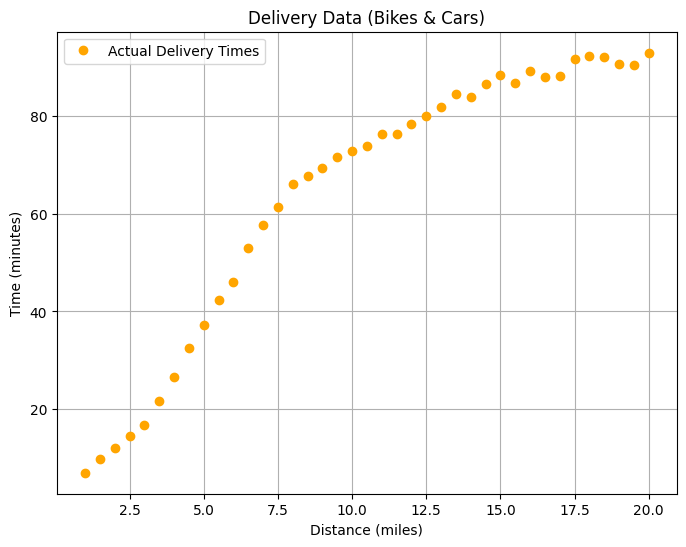

In [3]:
helper_utils.plot_data(distances, times)

In [4]:
distances_mean = distances.mean()
distances_std = distances.std()
times_mean = times.mean()
times_std = times.std()
distances_norm = (distances - distances_mean) / distances_std
times_norm = (times - times_mean) / times_std

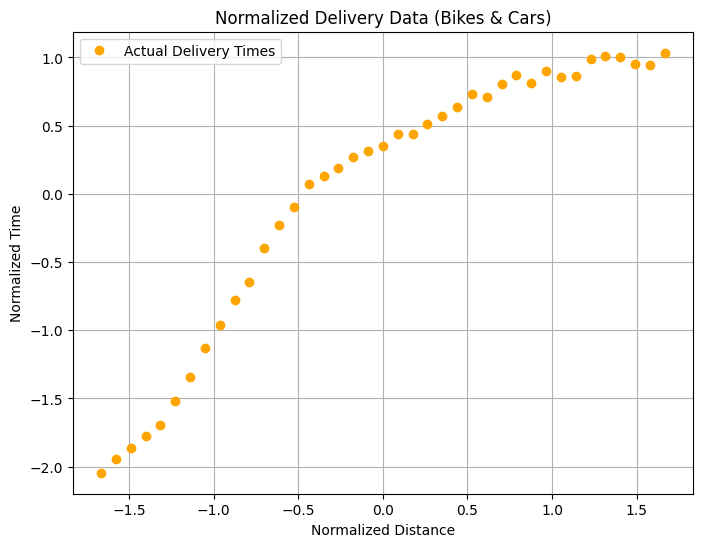

In [5]:
helper_utils.plot_data(distances_norm, times_norm, normalize=True)

In [6]:
torch.manual_seed(27)
model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1))

In [7]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

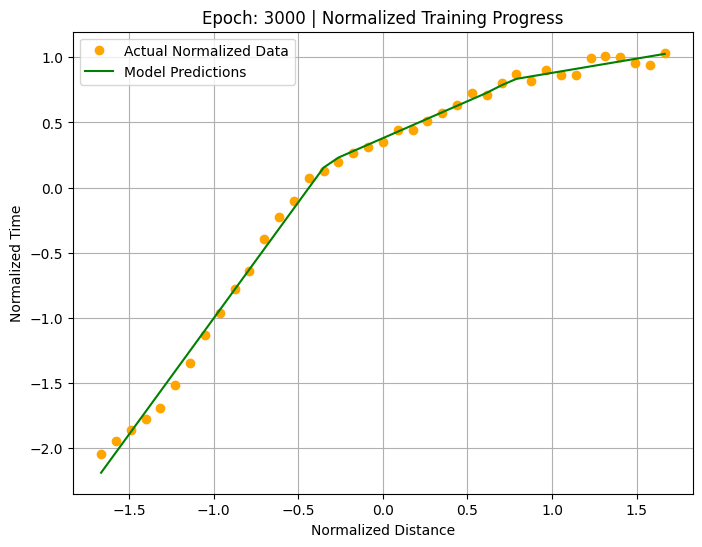


Training Complete.
Final Loss: 0.0031437124125659466


In [8]:
for epoch in range(3000):
    optimizer.zero_grad()
    outputs = model(distances_norm)
    loss = loss_function(outputs, times_norm)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        helper_utils.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm)
print('\nTraining Complete.')
print(f'Final Loss: {loss.item()}')

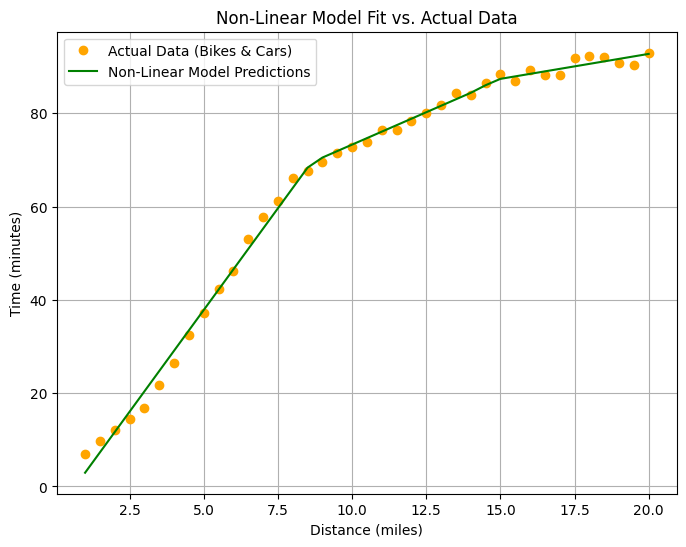

In [9]:
helper_utils.plot_final_fit(
    model, distances, times, distances_norm, times_std, times_mean)

In [10]:
distance_to_predict = 5.1

with torch.no_grad():
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    predicted_time_norm = model(new_distance_norm)
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    print(
        f'Prediction for a {distance_to_predict}-mile delivery: '
        f'{predicted_time_actual.item():.1f} minutes')
    if predicted_time_actual.item() > 45:
        print('\nDecision: Do NOT promise the delivery in under 45 minutes.')
    else:
        if distance_to_predict <= 3:
            print(
                f'\nDecision: Yes, delivery is possible. Since the distance is '
                f'{distance_to_predict} miles (<= 3 miles), use a bike.')
        else:
            print(
                f'\nDecision: Yes, delivery is possible. Since the distance is '
                f'{distance_to_predict} miles (> 3 miles), use a car.')

Prediction for a 5.1-mile delivery: 38.7 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.
